# Gambler's Ruin Statistics

## Why are we interested in statistics?

In a Monte Carlo simulation like Gambler's Ruin , we are **not** just interested in the results of one game. The results of one game are totally due to chance... like if you made only one bet in Las Vegas and left. We are more interested in what happens when we play the game over and over again. Can we see trends or averages that characterize the game?

For example:

> How does the one-game probability of gambler1 winning affect his/her chances of going broke?

> How does the relative capital amount that each gambler starts with affect the outcome?

> How do these parameters affect the average number of steps to bankruptcy (length of the game)?


To capture this important information, we must run the game hundreds or thousands of times and gather **statistics** on the outcomes.




## Plotting a histogram

In the cell below, we will run the gambler's ruin game multiple times with the same input parameters ( p, g1, g2) and capture data from the outcome of each game in new variables.

Then, we will print the key statistics (averages) for the simulation and plot a special kind of graph, called a **histogram** which categories and plots the game results by outcome. A **histogram** is a graphical display of data using bars of different heights. In our case, we will use a histogram to show the frequency distribution of the length (number of steps) of games in our simulated sample.

Below is an example of a **histogram** we will run.


<img src="gambler1_hist.png" width="500" align="center">

# Exercise: Gambler's Ruin Statistics

In the cell below, **you are asked to complete the for loop**  (mid-way in the program) which executes the game a specific number of times as entered by the user into variable named **num_sim**.


Only two or three lines of code will suffice to solve problem, so don't get too verbose!


## Note: Solution to this exercise is given in solutions notebook if you get stuck.

Don't give up too soon, however. This may require a little thought.


### Execute the following cell to make plot appear inside the notebook

In [ ]:
%matplotlib inline

Enter probability of gambler1 winning:  0.51
Enter bankroll for gambler1: 1000
Enter bankroll for gambler2: 1000
Enter number of simulations to run: 10000
0\10000
1000\10000
2000\10000
3000\10000
4000\10000
5000\10000
6000\10000
7000\10000
8000\10000
9000\10000
Statistics for gamblers ruin with 10000 simulations:

   Prob g1 =0.51, g1 bankroll = 1000, g2 bankroll = 1000
   Gambler1 wins 100 % of time
   Average number of steps to ruin is: 49935
   Largest number of steps to ruin is: 102302


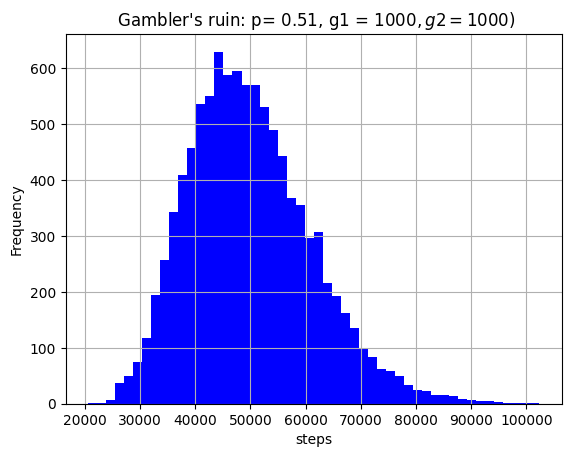

In [ ]:
import sys
import random as random
import numpy as np
import matplotlib.pyplot as plt

def gamble(p1, g1_amt, g2_amt):
    g1_seq = [g1_amt]
    g2_seq = [g2_amt]
    cur_g1 = g1_amt
    cur_g2 = g2_amt
    steps  = 0


    while cur_g1 > 0 and cur_g2 > 0 :
        if random.uniform(0,1) < p1 :  #   g1 wins, g2 loses!
            cur_g1 += 1
            cur_g2 -= 1
        else:                          #   g2 wins, g1 loses!
            cur_g1 -= 1
            cur_g2 += 1
        g1_seq.append(cur_g1)          #  Add to g1 and g2 sequence lists
        g2_seq.append(cur_g2)
        steps += 1

    return g1_seq, g2_seq, steps


#   Enter data from keyboard:
#        p, g1, g2, num_sim
#

p = float(input('Enter probability of gambler1 winning:  '))

if p<= 0.0 or p>=1 :
    print ('Probability entered =', p, ' prob must be between 0 and 1')
    sys.exit(0)

g1 = int(input('Enter bankroll for gambler1: '))
g2 = int(input('Enter bankroll for gambler2: '))

if g1<=0 or g2<=0:
    print ('Bankrolls entered were g1=', g1, 'and g2= ', g2,' Both must be > 0')
    sys.exit(0)

num_sim = int(input('Enter number of simulations to run: '))


#   Set up variables to accumulate number of steps to ruin and number of wins by g1
ruin_steps = np.zeros(num_sim)
g1_wins = 0


#   Execute main loop 'num_sim'  times
for num in range(num_sim):
    if (num%1000 == 0):
        print(f'{num}\\{num_sim}')

    g1_walk, g2_walk, steps = gamble(p, g1, g2)

    ruin_steps[num] = steps

    if g2_walk[-1] == 0:
        g1_wins += 1


############################################################
#   YOUR CODE GOES HERE
#     Complete this for-loop to capture each games output
#     in following variables:
#        1) number of steps for each game is stored in
#           array ruin_steps (indexed by game number)
#        2) Each time g1 wins we increment g1_wins by one
#
#        Hint: g1 wins if end of g2_walk = 0 ( g2_walk[-1] == 0)
#############################################################


#   Print out key statistics and plot histogram of number of steps to ruin
g1_win_percent = round(100.0*(g1_wins/float(num_sim)))
print (f'Statistics for gamblers ruin with {num_sim} simulations:\n')
print (f'   Prob g1 ={p}, g1 bankroll = {g1}, g2 bankroll = {g2}' )
print (f'   Gambler1 wins {g1_win_percent} % of time')
print (f'   Average number of steps to ruin is: {int(np.mean(ruin_steps))}')
print (f'   Largest number of steps to ruin is: {int(np.max(ruin_steps))}' )
plt.hist(ruin_steps, bins=50, color='blue')
plt.title(f" Gambler's ruin: p= {p}, g1 = ${g1}, g2 = ${g2})")
plt.xlabel('steps')
plt.ylabel('Frequency')
plt.grid(True)
#plt.savefig('gambler1_hist.png')
plt.show()

# Running Experiments with Gambler's Ruin Statistics


## Now, that we have the our statistics program running we can really have some fun  !!



Let's test a few of our original assumptions about Gambler's Ruin:

>  1. The probability that the first gambler eventually goes bankrupt is $M2/(M1 + M2)$ given that the first has a bankroll of $M1$ dollars and the second has $M2$ dollars and they play a fair game (probability p = 1/2 of each one winning).


Devise an experiment to test this assumption with the program, run the experiment, and plot your result (manually) Note: Keep the number of simulations to 1000 for each run, to keep running time down.


> 2. Another interesting result is that the expected time until one or the other goes broke is $\tau = M1* M2$.

Devise an experiment to test this assumption with the program, run the experiment, and plot your result (manually)

  
> 3. What happens when we vary 'p' , the probability of g1 winning? For example, the casinos do not necessarily run a "fair" game with their patrons. They have to make money, right?? What if p were .6, or.55, or .51, or even .501 (g1 win 501 times out of 1000, on average), would casino (g1) win all of the games?

Devise an experiment to test the effect of changing g1's probability of winning and run the experiment   



For p=0.6, Casino won 1000 out of 1000 games.


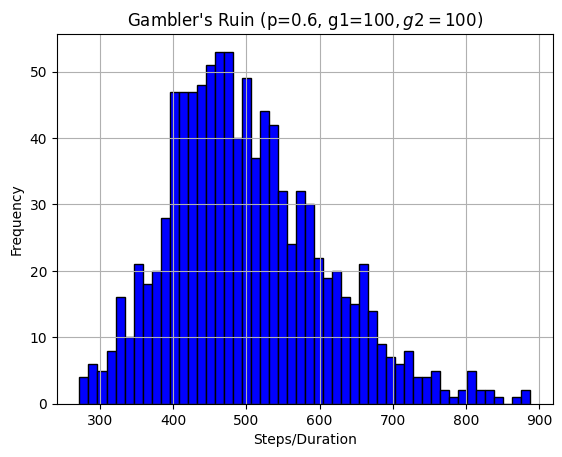

For p=0.55, Casino won 1000 out of 1000 games.


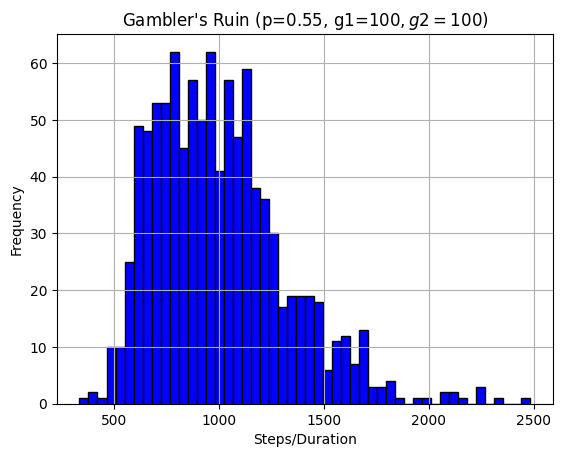

For p=0.51, Casino won 974 out of 1000 games.


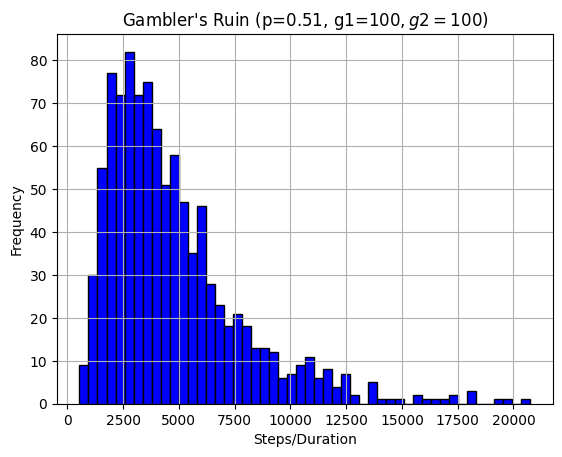

For p=0.501, Casino won 602 out of 1000 games.


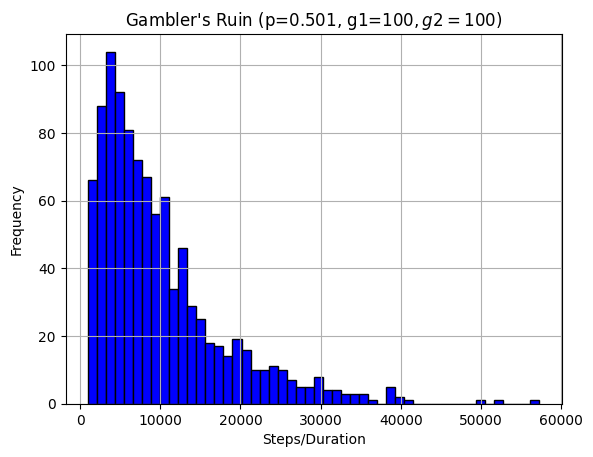

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

def gamble(p1, g1_amt, g2_amt):
    g1_seq = [g1_amt]
    g2_seq = [g2_amt]
    cur_g1 = g1_amt
    cur_g2 = g2_amt
    steps = 0
    while cur_g1 > 0 and cur_g2 > 0 and steps < 100000:
        if random.uniform(0, 1) < p1:
            cur_g1 += 1
            cur_g2 -= 1
        else:
            cur_g1 -= 1
            cur_g2 += 1
        g1_seq.append(cur_g1)
        g2_seq.append(cur_g2)
        steps += 1
    return g1_seq, g2_seq, steps

tested_p = [0.6, 0.55, 0.51, 0.501]
g1_amt = 100
g2_amt = 100

for p in tested_p:
    steps_count = []
    g1_wins = 0

    for _ in range(1000):
        casino, player, steps = gamble(p, g1_amt, g2_amt)
        steps_count.append(steps)
        if casino[-1] > player[-1]:
            g1_wins += 1

    print(f"For p={p}, Casino won {g1_wins} out of 1000 games.")

    plt.figure()
    plt.hist(steps_count, bins=50, color='blue', edgecolor='black')
    plt.title(f"Gambler's Ruin (p={p}, g1=${g1_amt}, g2=${g2_amt})")
    plt.xlabel('Steps/Duration')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()